# ASCAL — Multi-Problem Evaluation

End-to-end evaluation notebook: multi-problem demo collection, 80/20 held-out
split, learning curves, version space size convergence curves, and ground-truth
direction checks.

**Domain:** configurable via `DOMAIN_NAME` below.  
**Reference:** `AlgorithmExplained.md §11–14`, `DebugPlan.md §6b`.

In [1]:
import sys, os, contextlib, io, tempfile, shutil, random as _random

sys.path.insert(0, os.path.join('..', 'src'))

from unified_planning.shortcuts import get_environment
from unified_planning.io import PDDLReader
import unified_planning

get_environment().credits_stream = None

from ascal.learner import Learner
from ascal.models import Literal, State, Action, Demonstration
from ascal.transitions import generate_lifted_demonstrations_from_problem

import matplotlib.pyplot as plt
print("Imports OK")

Imports OK


## 1. Configuration

In [2]:
# ── Change only DOMAIN_NAME to switch domains ────────────────────────────
DOMAIN_NAME = "blocks"   # "blocks" | "driverlog" | "miconic" | "satellite"

# Per-domain settings:
#   sim_domain          : always domain_original.pddl  (see AlgorithmExplained §14c)
#   max_neg_step        : max negatives kept per plan step (after applicability check)
#   max_check_per_action: max groundings sampled PER ACTION per step BEFORE checking.
#                         500+ is effectively uncapped for small domains (blocks/miconic have <200 groundings).
#                         Set to a number for large domains where enumerating all
#                         groundings is the bottleneck (e.g. satellite take_image ≈768).
#   train_ratio         : fraction of problems used for training
DOMAIN_CONFIG = {
    "blocks":    dict(sim_domain="domain_extended.pddl", max_neg_step=50, max_check_per_action=500, train_ratio=0.8),
    "driverlog": dict(sim_domain="domain_original.pddl", max_neg_step=30, max_check_per_action=200, train_ratio=0.8),
    "miconic":   dict(sim_domain="domain_original.pddl", max_neg_step=50, max_check_per_action=500, train_ratio=0.8),
    "satellite": dict(sim_domain="domain_original.pddl", max_neg_step=30, max_check_per_action=100, train_ratio=0.8),
}

cfg          = DOMAIN_CONFIG[DOMAIN_NAME]
HERE         = os.path.abspath('.')
BENCH_DIR    = os.path.join(HERE, '..', 'benchmarks', DOMAIN_NAME)
DOMAIN_FILE  = os.path.join(BENCH_DIR, cfg["sim_domain"])
PROBLEMS_DIR = os.path.join(BENCH_DIR, 'problems')

print(f'Domain      : {DOMAIN_FILE}')
print(f'Problems    : {PROBLEMS_DIR}')
print(f'Domain exists  : {os.path.exists(DOMAIN_FILE)}')
print(f'Problems exists: {os.path.exists(PROBLEMS_DIR)}')

all_problem_files = sorted(f for f in os.listdir(PROBLEMS_DIR) if f.endswith('.pddl'))
print(f'Problems found : {len(all_problem_files)}')
print(f'Config         : {cfg}')

Domain      : /home/pablo/ASCAL/notebooks/../benchmarks/blocks/domain_extended.pddl
Problems    : /home/pablo/ASCAL/notebooks/../benchmarks/blocks/problems
Domain exists  : True
Problems exists: True
Problems found : 21
Config         : {'sim_domain': 'domain_extended.pddl', 'max_neg_step': 50, 'max_check_per_action': 500, 'train_ratio': 0.8}


## 2. Demo Generation

In [3]:
def generate_demos(problem, max_neg_per_step=50, max_check_per_action=None, seed=0):
    """Thin wrapper around :func:`ascal.transitions.generate_lifted_demonstrations_from_problem`."""
    return generate_lifted_demonstrations_from_problem(
        problem,
        max_neg_per_step=max_neg_per_step,
        max_check_per_action=max_check_per_action,
        seed=seed,
        verbose=False,
    )


def collect(files, max_neg_per_step=None, max_check_per_action=None, seed=42):
    """Collect unique lifted demos from a list of problem filenames.
    Defaults are taken from the domain cfg dict.
    """
    mnps = max_neg_per_step if max_neg_per_step is not None else cfg["max_neg_step"]
    mcpa = max_check_per_action if max_check_per_action is not None else cfg["max_check_per_action"]
    seen_pos, seen_neg = set(), set()
    pos_out, neg_out = [], []
    for pf in files:
        prob = PDDLReader().parse_problem(
            DOMAIN_FILE, os.path.join(PROBLEMS_DIR, pf)
        )
        td = tempfile.mkdtemp(prefix="ascal_mp_")
        cwd = os.getcwd()
        os.chdir(td)
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                p, n = generate_demos(
                    prob,
                    max_neg_per_step=mnps,
                    max_check_per_action=mcpa,
                    seed=seed,
                )
        finally:
            os.chdir(cwd)
            shutil.rmtree(td, ignore_errors=True)
        for d in p:
            k = repr(d)
            if k not in seen_pos:
                seen_pos.add(k)
                pos_out.append(d)
        for d in n:
            k = repr(d)
            if k not in seen_neg:
                seen_neg.add(k)
                neg_out.append(d)
    return pos_out, neg_out


print("generate_demos and collect defined.")


def compute_saturation_curve(
    all_files: list,
) -> tuple[list[int], dict[str, list[int]]]:
    """Count cumulative unique *positive* demonstrations after each problem.

    Only positive demos are generated (max_check_per_action=0 skips the
    negative-grounding loop entirely), so this runs quickly.

    Returns:
        total_curve:     [0, n1, n2, ...] — cumulative unique positives
                         after each problem (index 0 = before any problems).
        per_action_curve: {action_name: [0, n1, ...]} — same breakdown
                          per action.
    """
    seen_total = set()
    seen_per = {a: set() for a in action_names}
    total_curve = [0]
    per_action_curve = {a: [0] for a in action_names}

    for pf in all_files:
        prob = PDDLReader().parse_problem(
            DOMAIN_FILE, os.path.join(PROBLEMS_DIR, pf)
        )
        td = tempfile.mkdtemp(prefix="ascal_sat_")
        cwd = os.getcwd()
        os.chdir(td)
        try:
            with contextlib.redirect_stdout(io.StringIO()):
                p, _ = generate_demos(
                    prob,
                    max_neg_per_step=0,
                    max_check_per_action=0,
                    seed=0,
                )
        finally:
            os.chdir(cwd)
            shutil.rmtree(td, ignore_errors=True)

        for d in p:
            k = repr(d)
            if k not in seen_total:
                seen_total.add(k)
                seen_per[d.action.name].add(k)
        total_curve.append(len(seen_total))
        for a in action_names:
            per_action_curve[a].append(len(seen_per[a]))

    return total_curve, per_action_curve

generate_demos and collect defined.


## 3. Collect Demos (80 / 20 split)

In [4]:
split_idx   = int(len(all_problem_files) * cfg["train_ratio"])
train_files = all_problem_files[:split_idx]
test_files  = all_problem_files[split_idx:]
print(f'Train problems: {len(train_files)}  |  Test problems: {len(test_files)}')

train_pos, train_neg = collect(train_files)
test_pos,  test_neg  = collect(test_files)
print(f'Train: {len(train_pos)} pos + {len(train_neg)} neg')
print(f'Test : {len(test_pos)} pos + {len(test_neg)} neg')

# Parse schema for learner initialisation
prob0       = PDDLReader().parse_problem(DOMAIN_FILE,
                  os.path.join(PROBLEMS_DIR, all_problem_files[0]))
all_fluents = prob0.fluents
all_actions = prob0.actions
static_fl   = prob0.get_static_fluents()
action_names = [a.name for a in all_actions]
print(f'Actions: {action_names}')

Train problems: 16  |  Test problems: 5
Train: 66 pos + 1679 neg
Test : 41 pos + 1285 neg
Actions: ['pickup', 'putdown', 'stack', 'unstack']


## 4. Training Loop

Interleave negatives and positives (one batch of negatives per positive),
then take a snapshot after every positive demo.

In [5]:
# Build interleaved sequence
if not train_pos:
    train_seq = list(train_neg)
elif not train_neg:
    train_seq = list(train_pos)
else:
    sz        = len(train_neg) / len(train_pos)
    train_seq = []
    for i, p in enumerate(train_pos):
        train_seq.extend(train_neg[int(sz * i):int(sz * (i + 1))])
        train_seq.append(p)

learner      = Learner(all_fluents, all_actions, static_fl)
eval_history   = []   # P/R/F1 per positive-demo snapshot
vs_history     = []   # version space sizes per snapshot
gated_history  = []   # convergence-gated P/R/F1 per snapshot

for idx, demo in enumerate(train_seq):
    learner.update(demo)
    if demo.post_state is None or not test_pos:
        continue

    # Evaluation snapshot
    f1_s,  f1_c,  p_s,  r_s,  p_c,  r_c         = learner.evaluate(test_pos, test_neg)
    f1_s2, f1_c2, p_s2, r_s2, p_c2, r_c2, status = learner.evaluate_repr(test_pos, test_neg)
    eval_history.append(dict(
        demo_idx=idx,
        p_s=p_s,   r_s=r_s,   f1_s=f1_s,
        p_c=p_c,   r_c=r_c,   f1_c=f1_c,
        p_s2=p_s2, r_s2=r_s2, f1_s2=f1_s2,
        p_c2=p_c2, r_c2=r_c2, f1_c2=f1_c2,
    ))

    # Version space snapshot
    vs = learner.version_space_size
    vs_history.append(dict(
        demo_idx  = idx,
        n_pre     = {a: vs[a]['n_pre']     for a in action_names},
        total     = {a: vs[a]['total']     for a in action_names},
        converged = {a: vs[a]['converged'] for a in action_names},
    ))

    # Convergence-gated snapshot
    f1_sg, f1_cg, p_sg, r_sg, p_cg, r_cg, gstatus = learner.evaluate_gated(test_pos, test_neg)
    n_conv = sum(1 for s in gstatus.values() if s['converged'])
    gated_history.append(dict(
        demo_idx=idx, n_converged=n_conv,
        p_sg=p_sg, r_sg=r_sg, f1_sg=f1_sg,
        p_cg=p_cg, r_cg=r_cg, f1_cg=f1_cg,
        gstatus=gstatus,
    ))

print(f'Training done.  Snapshots: {len(eval_history)}')
print(f'Converged: {learner.converged}')

Training done.  Snapshots: 66
Converged: False


## 5. Final Held-Out Evaluation

In [6]:
if not test_pos:
    print('No test positives — held-out evaluation skipped.')
else:
    f1_s,  f1_c,  p_s,  r_s,  p_c,  r_c         = learner.evaluate(test_pos, test_neg)
    f1_s2, f1_c2, p_s2, r_s2, p_c2, r_c2, status = learner.evaluate_repr(test_pos, test_neg)

    print('=== FINAL HELD-OUT EVALUATION ===')
    print(f'  evaluate()      — Sound: P={p_s:.4f}  R={r_s:.4f}  F1={f1_s:.4f}'
          f'  |  Complete: P={p_c:.4f}  R={r_c:.4f}  F1={f1_c:.4f}')
    print(f'  evaluate_repr() — Sound: P={p_s2:.4f}  R={r_s2:.4f}  F1={f1_s2:.4f}'
          f'  |  Complete: P={p_c2:.4f}  R={r_c2:.4f}  F1={f1_c2:.4f}')
    print()
    print('  Per-action convergence:')
    for a, s in status.items():
        tag = '✓ converged' if s['converged'] else f' {s["n_hyps"]} hyps remaining'
        print(f'    {a}: {tag}')
    print(f'\n  Test set: {len(test_pos)} pos  {len(test_neg)} neg')

=== FINAL HELD-OUT EVALUATION ===
  evaluate()      — Sound: P=1.0000  R=1.0000  F1=1.0000  |  Complete: P=1.0000  R=1.0000  F1=1.0000
  evaluate_repr() — Sound: P=1.0000  R=1.0000  F1=1.0000  |  Complete: P=1.0000  R=1.0000  F1=1.0000

  Per-action convergence:
    pickup:  1 hyps remaining
    putdown:  1 hyps remaining
    stack:  1 hyps remaining
    unstack:  1 hyps remaining

  Test set: 41 pos  1285 neg


## 6. Learning Curves (P / R / F1)

Precision, Recall, and F1 evaluated on the **held-out test set** at every
positive-demo snapshot. The dotted line at 1.0 marks the theoretical guarantees
(C1: sound precision ≡ 1, C2: complete recall ≡ 1).

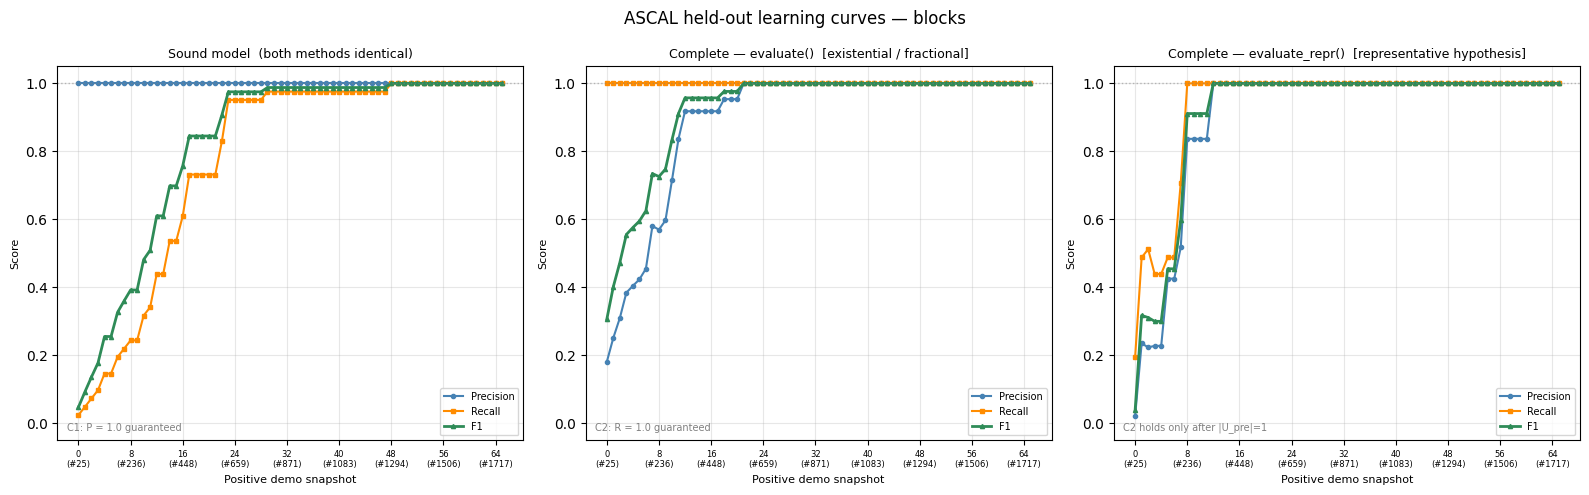

In [7]:
if len(eval_history) < 2:
    print('(Need ≥ 2 snapshots to plot.)')
else:
    snap_idx  = list(range(len(eval_history)))
    demo_idxs = [m['demo_idx'] for m in eval_history]

    # Find first snapshot where ALL actions have |U_pre|=1
    pre_conv_snap = None
    for i, m in enumerate(vs_history):
        if all(m['n_pre'][a] == 1 for a in action_names):
            pre_conv_snap = i
            break

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'ASCAL held-out learning curves — {DOMAIN_NAME}', fontsize=12)

    step     = max(1, len(snap_idx) // 8)
    tick_pos = snap_idx[::step]
    xlbls    = [f'{i}\n(#{demo_idxs[i]})' for i in tick_pos]

    panels = [
        (axes[0], 'Sound model  (both methods identical)',
         'p_s', 'r_s', 'f1_s',
         'C1: P = 1.0 guaranteed'),
        (axes[1], 'Complete — evaluate()  [existential / fractional]',
         'p_c', 'r_c', 'f1_c',
         'C2: R = 1.0 guaranteed'),
        (axes[2], 'Complete — evaluate_repr()  [representative hypothesis]',
         'p_c2', 'r_c2', 'f1_c2',
         'C2 holds only after |U_pre|=1'),
    ]

    for ax, title, pk, rk, f1k, note in panels:
        ax.plot(snap_idx, [m[pk]  for m in eval_history],
                marker='o', markersize=3, label='Precision', color='steelblue')
        ax.plot(snap_idx, [m[rk]  for m in eval_history],
                marker='s', markersize=3, label='Recall',    color='darkorange')
        ax.plot(snap_idx, [m[f1k] for m in eval_history],
                marker='^', markersize=3, label='F1',        color='seagreen', linewidth=2)
        ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.5)
        # Mark convergence point
        # if pre_conv_snap is not None:
        #    ax.axvline(pre_conv_snap, color='red', linestyle='--', linewidth=1.2,
        #              alpha=0.7, label=f'|U_pre|=1 (snap {pre_conv_snap})')
        ax.set_title(title, fontsize=9)
        ax.set_xlabel('Positive demo snapshot', fontsize=8)
        ax.set_ylabel('Score', fontsize=8)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(tick_pos)
        ax.set_xticklabels(xlbls, fontsize=6)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.text(0.02, 0.02, note, transform=ax.transAxes,
                fontsize=7, color='gray', va='bottom')

    plt.tight_layout()
    plt.show()

## 7. Version Space Size Curves

How many hypotheses remain in `U_pre` for each action as more demonstrations
arrive? This is the most direct measure of **convergence speed**.

- **Left** — `|U_pre|` (hypothesis count per action, log scale)
- **Right** — Total version space size `n_pre × n_eff` (log scale, capped at 10⁶)

The algorithm is fully converged when all curves touch the dashed line at 1.

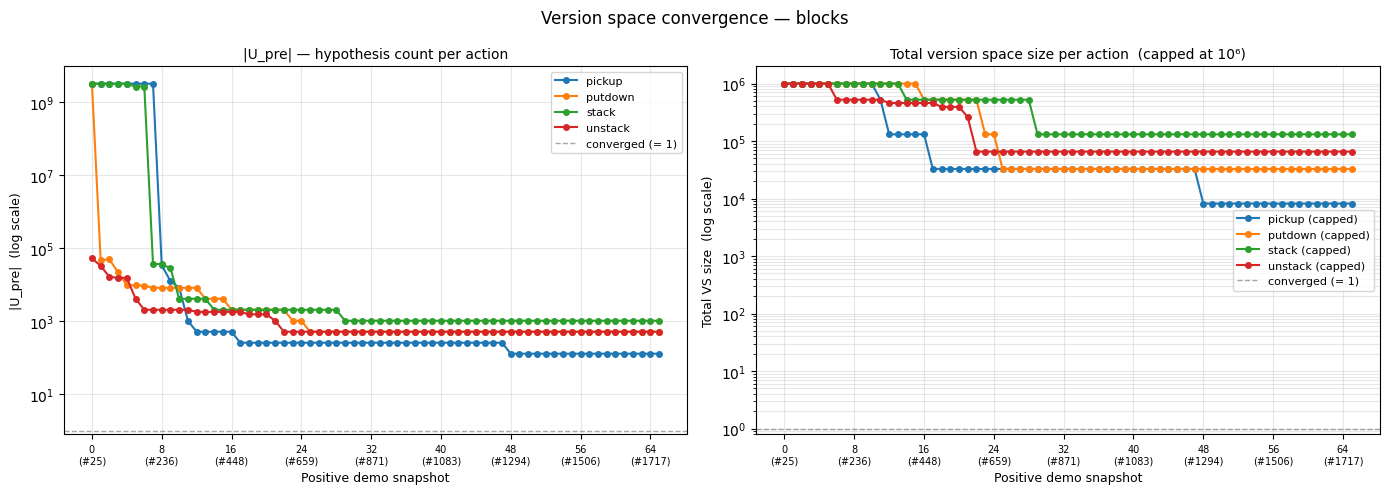


Convergence summary at final snapshot:
  pickup                   : |U_pre|= 128  total=8.2e+03   128 hyps
  putdown                  : |U_pre|= 512  total=3.3e+04   512 hyps
  stack                    : |U_pre|=1024  total=1.3e+05   1024 hyps
  unstack                  : |U_pre|= 512  total=6.6e+04   512 hyps


In [8]:
if len(vs_history) < 2:
    print('(Need ≥ 2 snapshots to plot.)')
else:
    snap_idx  = list(range(len(vs_history)))
    demo_idxs = [m['demo_idx'] for m in vs_history]
    CAP       = 1e6

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Version space convergence — {DOMAIN_NAME}', fontsize=12)

    step     = max(1, len(snap_idx) // 8)
    tick_pos = snap_idx[::step]

    # Left: |U_pre| hypothesis count
    ax = axes[0]
    for aname in action_names:
        y = [m['n_pre'][aname] for m in vs_history]
        ax.plot(snap_idx, y, marker='o', markersize=4, label=aname)
    ax.axhline(1, color='gray', linestyle='--', linewidth=1, alpha=0.7,
               label='converged (= 1)')
    ax.set_title('|U_pre| — hypothesis count per action', fontsize=10)
    ax.set_xlabel('Positive demo snapshot', fontsize=9)
    ax.set_ylabel('|U_pre|  (log scale)', fontsize=9)
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.8)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f'{i}\n(#{demo_idxs[i]})' for i in tick_pos], fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

    # Right: total version space size
    ax = axes[1]
    for aname in action_names:
        raw = [m['total'][aname] for m in vs_history]
        y   = [min(v, CAP) for v in raw]
        lbl = aname + (' (capped)' if any(v >= CAP for v in raw) else '')
        ax.plot(snap_idx, y, marker='o', markersize=4, label=lbl)
    ax.axhline(1, color='gray', linestyle='--', linewidth=1, alpha=0.7,
               label='converged (= 1)')
    ax.set_title('Total version space size per action  (capped at 10⁶)', fontsize=10)
    ax.set_xlabel('Positive demo snapshot', fontsize=9)
    ax.set_ylabel('Total VS size  (log scale)', fontsize=9)
    ax.set_yscale('log')
    ax.set_ylim(bottom=0.8)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f'{i}\n(#{demo_idxs[i]})' for i in tick_pos], fontsize=7)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which='both')

    plt.tight_layout()
    plt.show()

    # Convergence summary table
    print('\nConvergence summary at final snapshot:')
    last = vs_history[-1]
    for aname in action_names:
        n   = last['n_pre'][aname]
        tot = last['total'][aname]
        tag = '✓ converged' if last['converged'][aname] else f' {n} hyps'
        print(f'  {aname:25s}: |U_pre|={n:4d}  total={tot:.1e}  {tag}')

---

## 8. Convergence-Gated Metrics

Report P/R/F1 **only for actions that have fully converged** (`|U_pre|=1` and
`L_eff=U_eff`). Non-converged actions are excluded from every numerator and
denominator, giving standard binary precision/recall that is directly comparable
with other papers.

- The top panel shows how many actions have converged at each snapshot.
- The bottom panels show aggregate gated P/R/F1 — these are `0.0` until at
  least one action converges, then jump to meaningful values.
- Once **all** actions converge, gated metrics are identical to `evaluate_repr()`.

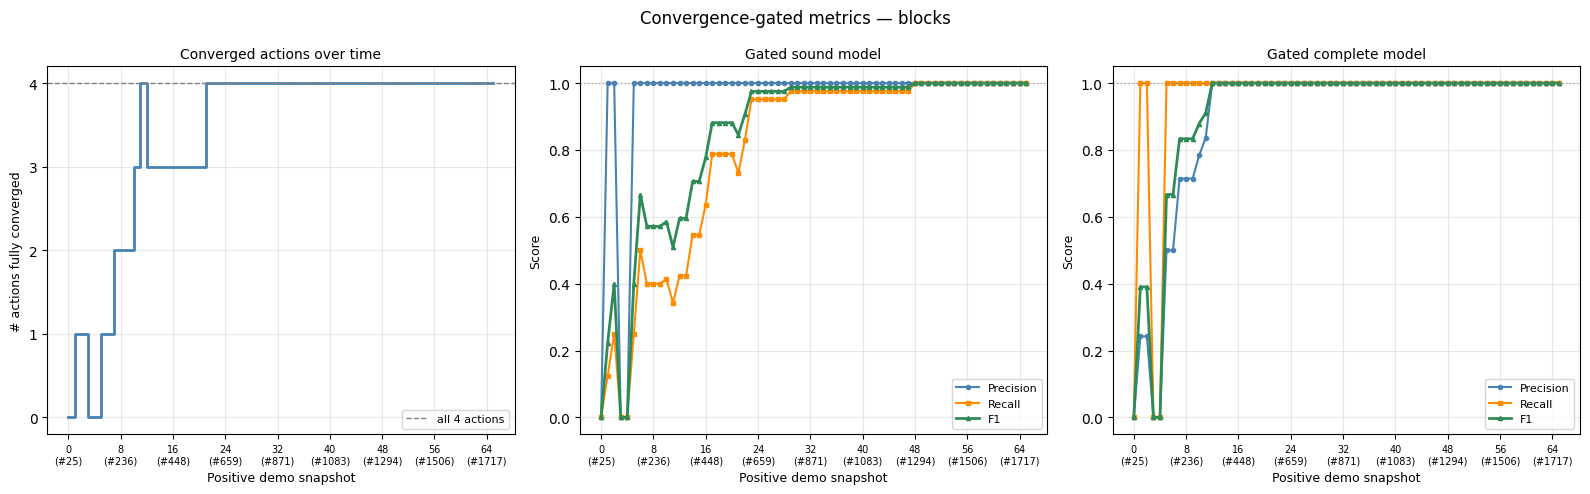


Per-action status at final snapshot:
  pickup                   :  converged  Sound F1=1.0000  Complete F1=1.0000
  putdown                  :  converged  Sound F1=1.0000  Complete F1=1.0000
  stack                    :  converged  Sound F1=1.0000  Complete F1=1.0000
  unstack                  :  converged  Sound F1=1.0000  Complete F1=1.0000


In [9]:
if len(gated_history) < 2:
    print('(Need ≥ 2 snapshots to plot.)')
else:
    snap_idx  = list(range(len(gated_history)))
    demo_idxs = [m['demo_idx'] for m in gated_history]
    n_actions = len(action_names)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'Convergence-gated metrics — {DOMAIN_NAME}', fontsize=12)

    step     = max(1, len(snap_idx) // 8)
    tick_pos = snap_idx[::step]
    xlbls    = [f'{i}\n(#{demo_idxs[i]})' for i in tick_pos]

    # Left: number of converged actions over time
    ax = axes[0]
    n_conv_curve = [m['n_converged'] for m in gated_history]
    ax.step(snap_idx, n_conv_curve, where='post', color='steelblue', linewidth=2)
    ax.axhline(n_actions, color='gray', linestyle='--', linewidth=1,
               label=f'all {n_actions} actions')
    ax.set_title('Converged actions over time', fontsize=10)
    ax.set_xlabel('Positive demo snapshot', fontsize=9)
    ax.set_ylabel('# actions fully converged', fontsize=9)
    ax.set_yticks(range(n_actions + 1))
    ax.set_xticks(tick_pos); ax.set_xticklabels(xlbls, fontsize=7)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Middle: gated sound model
    ax = axes[1]
    ax.plot(snap_idx, [m['p_sg']  for m in gated_history],
            marker='o', markersize=3, label='Precision', color='steelblue')
    ax.plot(snap_idx, [m['r_sg']  for m in gated_history],
            marker='s', markersize=3, label='Recall',    color='darkorange')
    ax.plot(snap_idx, [m['f1_sg'] for m in gated_history],
            marker='^', markersize=3, label='F1',        color='seagreen', linewidth=2)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title('Gated sound model', fontsize=10)
    ax.set_xlabel('Positive demo snapshot', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(tick_pos); ax.set_xticklabels(xlbls, fontsize=7)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # Right: gated complete model
    ax = axes[2]
    ax.plot(snap_idx, [m['p_cg']  for m in gated_history],
            marker='o', markersize=3, label='Precision', color='steelblue')
    ax.plot(snap_idx, [m['r_cg']  for m in gated_history],
            marker='s', markersize=3, label='Recall',    color='darkorange')
    ax.plot(snap_idx, [m['f1_cg'] for m in gated_history],
            marker='^', markersize=3, label='F1',        color='seagreen', linewidth=2)
    ax.axhline(1.0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title('Gated complete model', fontsize=10)
    ax.set_xlabel('Positive demo snapshot', fontsize=9)
    ax.set_ylabel('Score', fontsize=9)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(tick_pos); ax.set_xticklabels(xlbls, fontsize=7)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Per-action summary at final snapshot
    print('\nPer-action status at final snapshot:')
    last_g = gated_history[-1]['gstatus']
    for aname in action_names:
        s = last_g[aname]
        if s['converged']:
            print(f'  {aname:25s}:  converged  '
                  f'Sound F1={s["f1_sound"]:.4f}  Complete F1={s["f1_complete"]:.4f}')
        else:
            print(f'  {aname:25s}:  {s["n_hyps"]} hyps  (excluded from gated metrics)')

## 9. Inline Sanity Checks

Quick Group A (structural invariants) and Group C (C1/C2 guarantees) checks
on the final learned model.

In [10]:
print('=== GROUP A: Structural Invariants ===')
a_ok = True
for aname in action_names:
    for hU in learner.U_pre[aname]:
        for hL in learner.L_pre[aname]:
            if not hU.issubset(hL):
                print(f'A1 violated: U_pre ⊄ L_pre for {aname}')
                a_ok = False
    for hL in learner.L_eff[aname]:
        for hU in learner.U_eff[aname]:
            if not hL.issubset(hU):
                print(f'A2 violated: L_eff ⊄ U_eff for {aname}')
                a_ok = False
if a_ok:
    print('  A1 (U_pre ⊆ L_pre) and A2 (L_eff ⊆ U_eff) hold for all actions.')

if test_pos:
    print()
    print('=== GROUP C: Theoretical Guarantees (final snapshot) ===')
    f1_s, f1_c, p_s, r_s, p_c, r_c = learner.evaluate(test_pos, test_neg)
    c1 = abs(p_s - 1.0) < 1e-9
    c2 = abs(r_c - 1.0) < 1e-9
    print(f'  C1 Sound precision = 1.0 : (P_s = {p_s:.6f})')
    print(f'  C2 Complete recall  = 1.0 : (R_c = {r_c:.6f})')

=== GROUP A: Structural Invariants ===
  A1 (U_pre ⊆ L_pre) and A2 (L_eff ⊆ U_eff) hold for all actions.

=== GROUP C: Theoretical Guarantees (final snapshot) ===
  C1 Sound precision = 1.0 : (P_s = 1.000000)
  C2 Complete recall  = 1.0 : (R_c = 1.000000)


---

## 10. Demo Saturation Curve

How many new *unique lifted positive* demonstrations does each additional
problem contribute?  When the curve flattens, extra problems provide no new
learning signal — the domain has **saturated**.

The plot is computed separately from training (only positive demos are
generated, so it runs quickly).

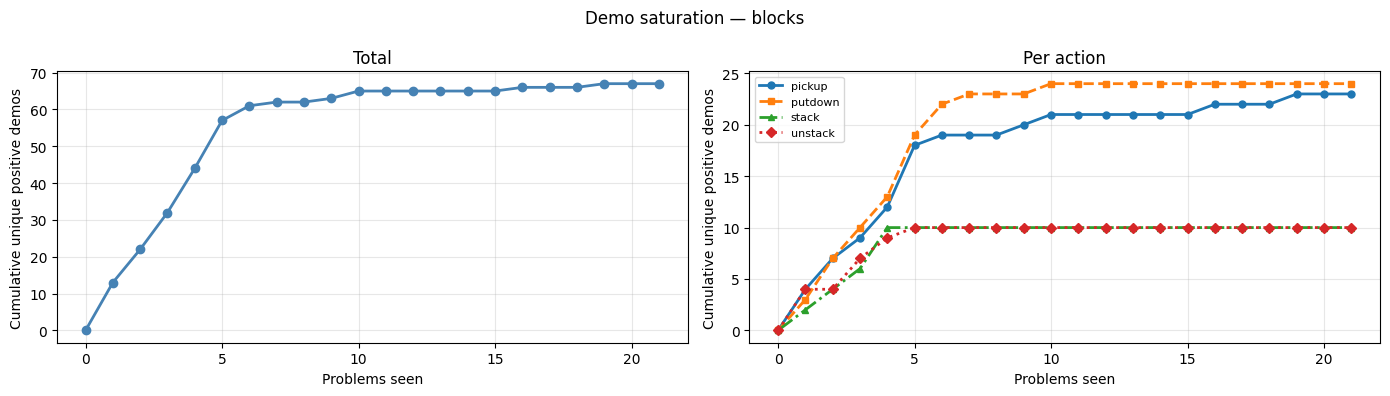

Unique positives per problem : [13, 9, 10, 12, 13, 4, 1, 0, 1, 2, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]
Saturation reached after 8 problem(s) — subsequent problems add 0 new demos.


In [11]:
sat_total, sat_per = compute_saturation_curve(all_problem_files)

x = list(range(len(sat_total)))   # 0 … n_problems

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Demo saturation — {DOMAIN_NAME}", fontsize=12)

# Left: total unique positives
axes[0].plot(x, sat_total, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Problems seen")
axes[0].set_ylabel("Cumulative unique positive demos")
axes[0].set_title("Total")
axes[0].grid(True, alpha=0.3)

# Right: per-action breakdown
# Use both colour AND line style so overlapping lines remain distinguishable
colours    = plt.rcParams["axes.prop_cycle"].by_key()["color"]
linestyles = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,1))]
markers    = ["o", "s", "^", "D", "v", "P"]
for j, a in enumerate(action_names):
    axes[1].plot(
        x, sat_per[a],
        label      = a,
        color      = colours[j % len(colours)],
        linestyle  = linestyles[j % len(linestyles)],
        marker     = markers[j % len(markers)],
        linewidth  = 2,
        markersize = 5,
    )
axes[1].set_xlabel("Problems seen")
axes[1].set_ylabel("Cumulative unique positive demos")
axes[1].set_title("Per action")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Numeric summary
increments = [sat_total[i+1] - sat_total[i] for i in range(len(sat_total)-1)]
sat_point  = next((i+1 for i, inc in enumerate(increments) if inc == 0), None)
print(f"Unique positives per problem : {increments}")
if sat_point:
    print(f"Saturation reached after {sat_point} problem(s) — subsequent problems add 0 new demos.")
else:
    print("No full saturation observed within the problem set.")

---

## 11. CSV Export

Save ``eval_history`` to ``benchmarks/<domain>/f1_results_<domain>.csv`` for
use by ``notebooks/Figures.ipynb`` and other analysis scripts.

Columns: ``snapshot``, ``demo_idx``, and P/R/F1 for both evaluation methods
(``evaluate`` and ``evaluate_repr``) — sound and complete models.

In [12]:
import csv

out_path = os.path.join('..', 'benchmarks', DOMAIN_NAME,
                         f'f1_results_{DOMAIN_NAME}.csv')
os.makedirs(os.path.dirname(out_path), exist_ok=True)

with open(out_path, 'w', newline='') as csvf:
    writer = csv.writer(csvf)
    writer.writerow([
        'snapshot', 'demo_idx',
        'p_sound',       'r_sound',       'f1_sound',
        'p_complete',    'r_complete',    'f1_complete',
        'p_sound_repr',  'r_sound_repr',  'f1_sound_repr',
        'p_complete_repr','r_complete_repr','f1_complete_repr',
    ])
    for i, m in enumerate(eval_history):
        writer.writerow([
            i,           m['demo_idx'],
            m['p_s'],    m['r_s'],    m['f1_s'],
            m['p_c'],    m['r_c'],    m['f1_c'],
            m['p_s2'],   m['r_s2'],   m['f1_s2'],
            m['p_c2'],   m['r_c2'],   m['f1_c2'],
        ])

print(f'Saved {len(eval_history)} rows → {os.path.abspath(out_path)}')

Saved 66 rows → /home/pablo/ASCAL/benchmarks/blocks/f1_results_blocks.csv
